In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

In [2]:
import os
print(os.listdir())

['FinalModel.ipynb', 'Untitled1.ipynb', '.DS_Store', 'anaconda_projects', 'Untitled.ipynb', 'chest_xray', 'final_output.jpg', 'Pneumonia_Detection_Project.ipynb', 'test1.jpg', 'test2.jpg', 'finalmodel.h5', 'static', 'mkdir', 'app.py', 'templates', '.ipynb_checkpoints', 'cd', 'myenv']


In [3]:
print(os.listdir('./chest_xray'))

['test', 'chest_xray', '__MACOSX', 'train', 'val']


In [4]:
train_dir = "./chest_xray/chest_xray/train"
val_dir = "./chest_xray/chest_xray/val"

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

In [6]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [7]:
baseline_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/opt/anaconda3/envs/orange3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
custom_model = Sequential([
    Conv2D(32,(3,3),activation='swish',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='swish'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='swish'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='swish'),
    Dense(1,activation='sigmoid')
])

custom_model.compile(
    optimizer='adamax',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

custom_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
baseline_history = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.8923 - loss: 0.4039 - val_accuracy: 0.9375 - val_loss: 0.2085
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.9638 - loss: 0.0956 - val_accuracy: 0.6875 - val_loss: 0.7461
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9737 - loss: 0.0712 - val_accuracy: 0.8750 - val_loss: 0.2713


In [10]:
custom_history = custom_model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.8587 - loss: 0.3331 - val_accuracy: 0.6875 - val_loss: 0.6716
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.9494 - loss: 0.1348 - val_accuracy: 0.9375 - val_loss: 0.3163
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.9551 - loss: 0.1181 - val_accuracy: 0.8125 - val_loss: 0.4281


In [11]:
print("Baseline Accuracy:", max(baseline_history.history['val_accuracy']))
print("Custom Accuracy:", max(custom_history.history['val_accuracy']))

Baseline Accuracy: 0.9375
Custom Accuracy: 0.9375


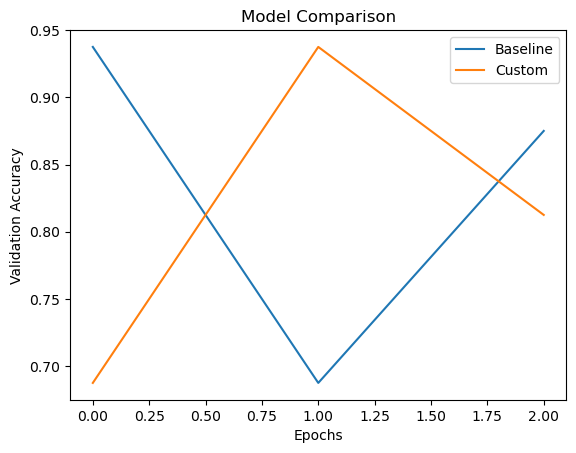

In [12]:
import matplotlib.pyplot as plt

plt.plot(baseline_history.history['val_accuracy'], label='Baseline')
plt.plot(custom_history.history['val_accuracy'], label='Custom')
plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.show()

In [13]:
custom_model.save("finalmodel.h5")

In [14]:
custom_model.save("finalmodel.keras")

In [15]:
dir()

['Conv2D',
 'Dense',
 'Flatten',
 'ImageDataGenerator',
 'In',
 'MaxPooling2D',
 'Out',
 'Sequential',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'baseline_history',
 'baseline_model',
 'custom_history',
 'custom_model',
 'exit',
 'get_ipython',
 'open',
 'os',
 'plt',
 'quit',
 'tf',
 'train_data',
 'train_dir',
 'train_gen',
 'val_data',
 'val_dir',
 'val_gen']

In [16]:
dir()

['Conv2D',
 'Dense',
 'Flatten',
 'ImageDataGenerator',
 'In',
 'MaxPooling2D',
 'Out',
 'Sequential',
 '_',
 '_15',
 '_16',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__pandas',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'baseline_history',
 'baseline_model',
 'custom_history',
 'custom_model',
 'dataframe_columns',
 'dataframe_hash',
 'dtypes_str',
 'exit',
 'get_dataframes',
 'get_ipython',
 'getpass',
 'hashlib',
 'import_pandas_safely',
 'is_data_frame',
 'json',
 'open',
 'os',
 'plt',
 'quit',
 'tf',
 'train_data',
 'train_dir',
 'train_gen',
 'val_data',
 'val_dir',
 'val_gen']

In [17]:
custom_model.save("finalmodel.keras")

In [18]:
custom_model.save("finalmodel.h5")